# EDA

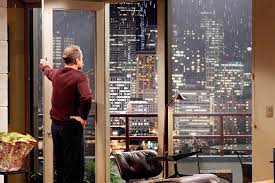

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("data/housing_cleaned.pkl")

**Zusammenfassung Phase 2:** Alle vier betroffenen Spalten sind jetzt vollständig, ohne dass wir Zeilen gelöscht oder Werte grob geraten haben – jede Entscheidung basiert auf einer inhaltlichen Begründung (dominanter Wert, Beziehung zwischen Spalten) oder auf einer verifizierten Korrektur.

---

## Hypothese 2 – "Renovation / Condition / Grade correspond to higher price points"

Diese Hypothese wurde mir (Sonson) vom Team zur Untersuchung zugeteilt. Sie deckt sich mit unserer Annahme zum "Condition Discount": Häuser mit durchschnittlichem Zustand (`condition == 3`) sollen einen günstigeren Einstiegspreis mit Renovierungspotenzial bieten. Wir prüfen das in zwei Schritten:

1. Zuerst auf dem **gesamten Datensatz**: Wie hängen `grade`, `condition` und Renovierungsstatus generell mit dem Preis zusammen?
2. Dann **gezielt in Bonnie Browns Budget-Segment** (`price <= 500.000`, `bedrooms >= 3`, `bathrooms >= 1.5`), auf Basis von `price / sqft_living` – denn ein absoluter Preisvergleich ist für sie irrelevant, ihr Budget ist ohnehin gedeckelt.

### 3.1 Preis nach `grade` (gesamter Datensatz)

`grade` ist King Countys eigenes Bewertungssystem für Bauqualität/-ausstattung (3 = niedrig, 13 = sehr hoch). Wir schauen uns die Preisverteilung je Grade-Stufe an.

       count     median          mean
grade                                
3          1   262000.0  2.620000e+05
4         27   200000.0  2.120019e+05
5        242   228700.0  2.485240e+05
6       2038   275276.5  3.019166e+05
7       8974   375000.0  4.025946e+05
8       6065   510000.0  5.429868e+05
9       2615   720000.0  7.737382e+05
10      1134   914327.0  1.072347e+06
11       399  1280000.0  1.497792e+06
12        89  1820000.0  2.202528e+06
13        13  2980000.0  3.710769e+06

Korrelation grade <-> price: 0.67


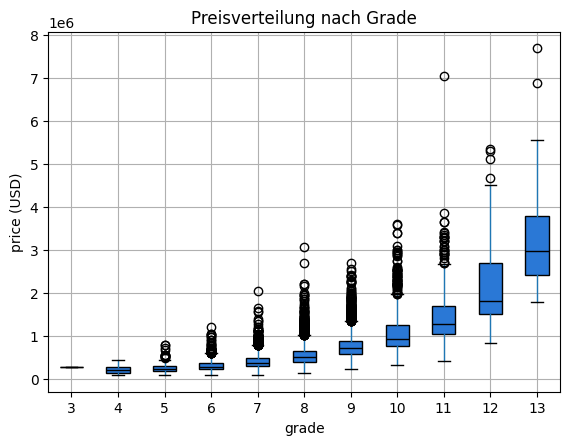

In [3]:
grade_price = df.groupby("grade")["price"].agg(["count", "median", "mean"])
print(grade_price)
print("\nKorrelation grade <-> price:", df["grade"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="grade", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Grade")
ax.set_xlabel("grade")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Sehr klarer, nahezu monotoner Zusammenhang – der Median-Preis steigt von 262.000 $ (Grade 3) auf 2.980.000 $ (Grade 13). Korrelation `grade` ↔ `price`: **0.67** – der stärkste Einzelfaktor, den wir bisher gesehen haben. Für Hypothese 2 heißt das: **Grade bestätigt die Hypothese eindeutig.**

**Observation:** A very clear, almost monotonic relationship — the median price rises from $262,000 (grade 3) to $2,980,000 (grade 13). Correlation `grade` ↔ `price`: **0.67** — the strongest single factor we've seen so far. For Hypothesis 2, this means: **grade clearly confirms the hypothesis.**

### 3.2 Preis nach `condition` (gesamter Datensatz)

`condition` bewertet den allgemeinen Erhaltungszustand (1 = schlecht, 5 = sehr gut).

           count    median           mean
condition                                
1             29  270000.0  341067.241379
2            170  279000.0  328178.758824
3          14020  450250.0  542173.057347
4           5677  440000.0  521374.450414
5           1701  526000.0  612577.742504

Korrelation condition <-> price: 0.04


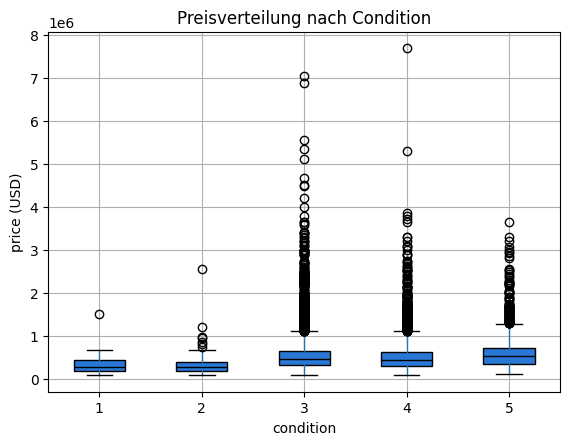

In [4]:
condition_price = df.groupby("condition")["price"].agg(["count", "median", "mean"])
print(condition_price)
print("\nKorrelation condition <-> price:", df["condition"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="condition", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Condition")
ax.set_xlabel("condition")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Anders als bei `grade` ist der Zusammenhang hier **schwach** – Korrelation `condition` ↔ `price`: nur **0.04**. `condition == 3` (Median 450.250 $) unterscheidet sich kaum von `condition == 4` (440.000 $) und liegt sogar leicht *unter* `condition == 5` (526.000 $), aber über `condition == 1`/`2` (kleine Stichproben, 29 bzw. 170 Häuser). Für Hypothese 2 heißt das: **`condition` allein erklärt den Preis über den gesamten Markt kaum** – der Effekt aus der Hypothese scheint fast ausschließlich über `grade` zu laufen, nicht über `condition`.

**Observation:** Unlike `grade`, the relationship here is **weak** — correlation `condition` ↔ `price`: only **0.04**. `condition == 3` (median $450,250) is barely different from `condition == 4` ($440,000), and even slightly *below* `condition == 5` ($526,000), though above `condition == 1`/`2` (small samples, 29 and 170 homes respectively). For Hypothesis 2, this means: **`condition` alone barely explains price across the whole market** — the effect implied by the hypothesis seems to run almost entirely through `grade`, not through `condition`.

### 3.3 Renovierte vs. nicht renovierte Häuser (gesamter Datensatz)

Wir leiten aus `yr_renovated` ein einfaches Flag `is_renovated` ab (`yr_renovated > 0`) und vergleichen sowohl den absoluten Preis als auch den Preis pro Quadratfuß (`price / sqft_living`), um Größeneffekte herauszurechnen.

              count    median           mean
is_renovated                                
False         20853  449000.0  532140.319858
True            744  607502.0  768901.892473

                  median        mean
is_renovated                        
False         243.190661  262.102755
True          301.562882  321.338135

Korrelation is_renovated <-> price: 0.12


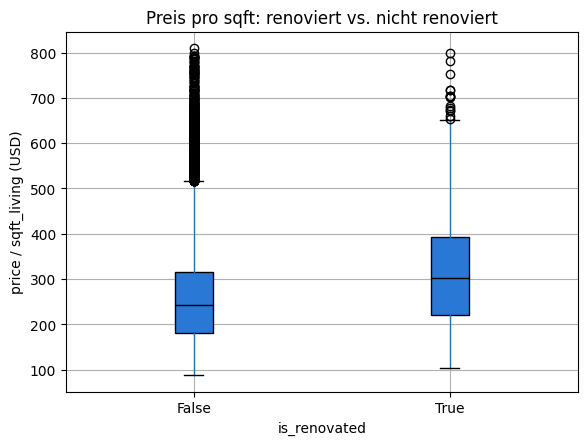

In [5]:
df["is_renovated"] = df["yr_renovated"] > 0
df["price_per_sqft"] = df["price"] / df["sqft_living"]

print(df.groupby("is_renovated")["price"].agg(["count", "median", "mean"]))
print()
print(df.groupby("is_renovated")["price_per_sqft"].agg(["median", "mean"]))
print("\nKorrelation is_renovated <-> price:", df["is_renovated"].astype(int).corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preis pro sqft: renoviert vs. nicht renoviert")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Renovierte Häuser (744 von 21.597, ca. 3.4 %) kosten median **607.502 $** vs. **449.000 $** bei nicht renovierten – auch pro Quadratfuß liegt der Median bei **302 $** vs. **243 $**. Korrelation `is_renovated` ↔ `price`: **0.12** – moderat, schwächer als `grade`, aber klar stärker als `condition`. Renovierung zeigt also einen sichtbaren Preisaufschlag.

**Observation:** Renovated homes (744 of 21,597, ~3.4%) sell for a median of **$607,502** vs. **$449,000** for non-renovated ones — the median price per square foot is also higher: **$302** vs. **$243**. Correlation `is_renovated` ↔ `price`: **0.12** — moderate, weaker than `grade` but clearly stronger than `condition`. Renovation does show a visible price premium.

### 3.4 Bonnies reale Rolle: Verkäuferin in einer Mittelschicht-Nachbarschaft

**Korrektur (Persona):** Die Analyse ab hier ging ursprünglich fälschlich davon aus, dass Bonnie eine Käuferin mit Budget ≤ 500.000 $ ist. Laut offizieller Aufgabenstellung (`01_assignment.md`) ist Bonnie Brown tatsächlich **Verkäuferin**: Sie besitzt bereits ein Haus in einer **Mittelschicht-Nachbarschaft** ("middle class NH"), will bald umziehen und dabei einen **möglichst hohen Profit** erzielen.

**Update (Pipeline, 2026-08-02):** Das Team hat sich inzwischen auf eine gemeinsame, teamweite Definition von "Mittelschicht-Nachbarschaft" geeinigt (`02_middle_class_neighbourhoods.ipynb`, Ergebnis in `data/middle_class_zip_pps.pkl`): Zipcodes werden dort nach **durchschnittlichem Preis pro Quadratfuß** (nicht Median-Preis wie in unserer ursprünglichen Version) in Terzile eingeteilt. Wir übernehmen jetzt diese geteilte Definition, um konsistent mit Hypothese 1 (Evelyn, bereits umgestellt) zu bleiben, statt unsere eigene Berechnung weiterzuführen.

In [6]:
bonnie = pd.read_pickle("data/middle_class_zip_pps.pkl")
bonnie["is_renovated"] = bonnie["yr_renovated"] > 0

print(f"Häuser in Mittelschicht-Nachbarschaften (Team-Pipeline): {len(bonnie)} ({len(bonnie) / len(df):.1%} des Gesamtmarkts)")
print(f"Zipcodes: {bonnie['zipcode'].nunique()} von {df['zipcode'].nunique()}")

Häuser in Mittelschicht-Nachbarschaften (Team-Pipeline): 7604 (35.2% des Gesamtmarkts)
Zipcodes: 24 von 70


**Beobachtung:** Mit der teamweiten Pipeline umfasst die Mittelschicht-Nachbarschaft **7.604 Häuser** (35,2 % des Marktes) in **24 Zipcodes** – etwas mehr als unsere ursprüngliche Version (6.791 Häuser, 22 Zipcodes). Wichtig: Es sind **nicht dieselben** Zipcodes – nur 10 der ca. 22–24 Zipcodes überlappen zwischen beiden Definitionen (Median-Preis vs. Preis/sqft). Das hat, wie sich unten zeigt, spürbare Auswirkungen auf unsere Ergebnisse.

#### `condition == 3` vs. andere Zustände – innerhalb der Mittelschicht-Nachbarschaften

In [7]:
bonnie.groupby(bonnie["condition"] == 3)["price_per_sqft"].agg(["count", "median", "mean"])

,count,median,mean
condition,,,
False,2202,251.835017,263.180194
True,5402,246.153846,251.386657


**Beobachtung:** Innerhalb der (neu definierten) Mittelschicht-Nachbarschaften liegt der Median-Preis pro Quadratfuß bei `condition == 3` (5.402 Häuser) bei **246 $**, verglichen mit **252 $** bei besser bewerteten Zuständen (2.202 Häuser) – ein Abschlag von nur noch rund **2 %** (zum Vergleich, mit unserer alten Segment-Definition: ~10 %). Der Discount zeigt in dieselbe Richtung, ist aber mit der teamweiten Definition deutlich schwächer.

#### ROI-Analyse: Lohnt sich eine Renovierung vor dem Verkauf?

Bonnies eigentliche Frage: Ihr Haus hat `condition == 3`. Würde eine Renovierung vor dem Verkauf den Gewinn ausreichend steigern, um sich zu lohnen? Wir vergleichen dazu bereits renovierte mit nicht renovierten Häusern, die *innerhalb* von `condition == 3` in Mittelschicht-Nachbarschaften verkauft wurden.

             price                          price_per_sqft              \
             count    median           mean          count      median   
is_renovated                                                             
False         5246  485000.0  541387.979032           5246  246.206365   
True           156  458000.0  547359.198718            156  238.343195   

                          
                    mean  
is_renovated              
False         251.303215  
True          254.192642  

Median-Preis renoviert: 458,000 $ vs. nicht renoviert: 485,000 $ -> -5.6 %
Median-Preis/sqft renoviert: 238 $ vs. nicht renoviert: 246 $ -> -3.2 %
Korrelation is_renovated <-> price: 0.0


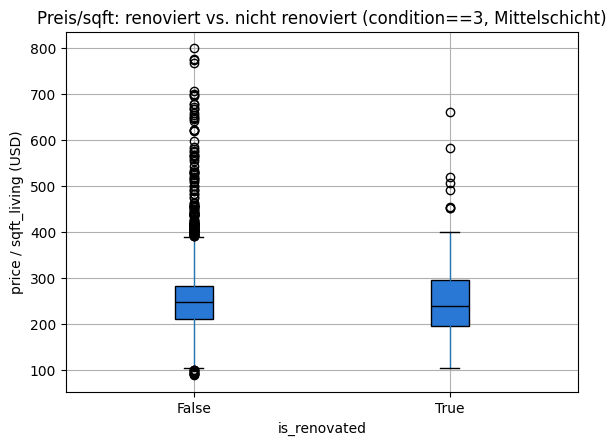

In [8]:
bonnie_cond3 = bonnie[bonnie["condition"] == 3].copy()

print(bonnie_cond3.groupby("is_renovated")[["price", "price_per_sqft"]].agg(["count", "median", "mean"]))

median_price_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price"].median()
median_price_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price"].median()
price_uplift_pct = (median_price_reno / median_price_noreno - 1) * 100

median_psf_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price_per_sqft"].median()
median_psf_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price_per_sqft"].median()
psf_uplift_pct = (median_psf_reno / median_psf_noreno - 1) * 100

print(f"\nMedian-Preis renoviert: {median_price_reno:,.0f} $ vs. nicht renoviert: {median_price_noreno:,.0f} $ -> {price_uplift_pct:+.1f} %")
print(f"Median-Preis/sqft renoviert: {median_psf_reno:,.0f} $ vs. nicht renoviert: {median_psf_noreno:,.0f} $ -> {psf_uplift_pct:+.1f} %")
print("Korrelation is_renovated <-> price:", bonnie_cond3["is_renovated"].astype(int).corr(bonnie_cond3["price"]).round(2))

fig, ax = plt.subplots()
bonnie_cond3.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
                     boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
                     medianprops={"color": "black"})
ax.set_title("Preis/sqft: renoviert vs. nicht renoviert (condition==3, Mittelschicht)")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Innerhalb von `condition == 3` in den (neu definierten) Mittelschicht-Nachbarschaften kosten bereits renovierte Häuser (156 von 5.402, ca. 2,9 %) median **458.000 $** vs. **485.000 $** bei nicht renovierten – das ist **−5,6 %** beim absoluten Preis bzw. **−3,2 %** beim Preis pro Quadratfuß (238 $ vs. 246 $). Korrelation `is_renovated` ↔ `price`: **0.00** – praktisch kein Zusammenhang mehr.

> ⚠️ **WICHTIGE KORREKTUR (2026-08-02): Dieses Ergebnis widerspricht direkt unserer vorherigen Analyse und der bereits präsentierten Empfehlung.**
>
> Mit unserer ursprünglichen (Median-Preis-basierten) Segment-Definition hatten wir einen **positiven** Renovierungs-Effekt gefunden (+36,7 % Preis, +21,7 % Preis/sqft, Korrelation 0.14) und Bonnie empfohlen, vor dem Verkauf zu renovieren. Mit der jetzt teamweit vereinbarten (Preis/sqft-basierten) Segment-Definition **kehrt sich das Ergebnis um**: kein positiver, sondern ein leicht negativer Effekt, praktisch keine Korrelation.
>
> **Warum der Unterschied?** Nicht durch einen Fehler in den Daten oder der Berechnung – beides wurde geprüft (Gesamtmarkt-Korrelationen stimmen exakt überein, `price_per_sqft` in der Pickle wurde gegengerechnet). Die beiden Methoden wählen schlicht **unterschiedliche Zipcodes** als "Mittelschicht" aus (nur 10 von ca. 22–24 überlappen). Der Renovierungs-Effekt, den wir vorher fanden, war offenbar spezifisch für die von uns ursprünglich gewählten Zipcodes, nicht robust über beide Definitionen hinweg.
>
> **Konsequenz:** Die Empfehlung "Renovierung vor dem Verkauf lohnt sich" **lässt sich mit der aktuellen, teamweit vereinbarten Datenbasis nicht mehr stützen.** Wir korrigieren unsere Schlussfolgerung entsprechend (siehe Zusammenfassung unten).

#### `grade` innerhalb der Mittelschicht-Nachbarschaften (Kontext)

Zur Einordnung: Gilt der starke Zusammenhang zwischen `grade` und Preis (3.1, Korrelation 0.67) auch innerhalb der Mittelschicht-Nachbarschaften, oder war er – wie in der alten, budget-limitierten Analyse – nur ein Artefakt des Budget-Deckels?

       count      median        mean
grade                               
4         13  322.077922  377.976969
5         66  250.000000  299.942829
6        781  260.245902  272.372462
7       2932  240.601504  247.746446
8       2106  247.792398  250.813036
9       1020  247.838663  253.976819
10       499  251.002825  265.552689
11       158  265.024481  279.442957
12        29  308.115543  336.438592

Korrelation grade <-> price (Mittelschicht-Segment): 0.75


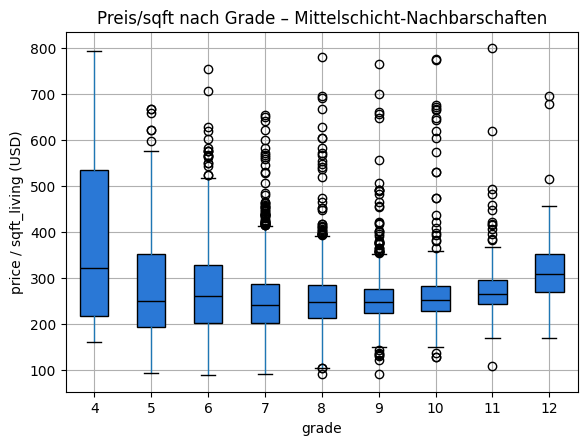

In [9]:
bonnie_grade = bonnie.groupby("grade")["price_per_sqft"].agg(["count", "median", "mean"])
print(bonnie_grade)
print("\nKorrelation grade <-> price (Mittelschicht-Segment):", bonnie["grade"].corr(bonnie["price"]).round(2))

fig, ax = plt.subplots()
bonnie.boxplot(column="price_per_sqft", by="grade", ax=ax, patch_artist=True,
               boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
               medianprops={"color": "black"})
ax.set_title("Preis/sqft nach Grade – Mittelschicht-Nachbarschaften")
ax.set_xlabel("grade")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Die Korrelation zwischen `grade` und Preis bleibt auch mit der neuen Segment-Definition stark – sogar etwas stärker als am Gesamtmarkt: **0.75** (vs. 0.67 gesamt; vorher 0.65 mit unserer alten Segment-Definition). `grade` ist also über beide Mittelschicht-Definitionen hinweg ein robuster Preistreiber – anders als die Renovierungs-/Zustands-Befunde, die sich mit der Segment-Definition deutlich verändern.

## Zusammenfassung Hypothese 2 (Renovation ROI)

> ⚠️ **Aktualisiert (2026-08-02):** Diese Zusammenfassung wurde nach Umstellung auf die teamweite Mittelschicht-Pipeline (`data/middle_class_zip_pps.pkl`) korrigiert. Die vorherige Version dieses Notebooks (siehe Git-Historie) empfahl eine Renovierung – das hält mit der jetzigen, teamweit vereinbarten Datenbasis **nicht mehr**.

| Faktor | Gesamtmarkt | Mittelschicht-Nachbarschaften (Team-Pipeline, Bonnies Segment) |
|---|---|---|
| `grade` | Starker Treiber (Korrelation 0.67) | Weiterhin starker Treiber (Korrelation 0.75) |
| `condition` | Schwach (Korrelation 0.04) | `condition == 3`: nur noch **~2 % Discount** ggü. besseren Zuständen (246 $ vs. 252 $/sqft) – vorher (alte Segment-Definition): ~10 % |
| Renovierung (condition==3) | Moderat (Korrelation 0.12), +35 % Median-Preis | **−5,6 %** Median-Preis, **−3,2 %** Preis/sqft bei renovierten Häusern (Korrelation 0.00) – vorher (alte Segment-Definition): **+36,7 % / +21,7 %** |

**Fazit für Bonnie Brown (Seller):** `grade` bleibt ein robuster Kontext-Preistreiber. Der `condition == 3`-Discount ist real, aber mit der teamweiten Segment-Definition kleiner als ursprünglich berichtet (~2 % statt ~10 %). **Der Renovierungs-Effekt, den wir vorher gefunden hatten, bestätigt sich mit der teamweiten Mittelschicht-Definition nicht** – der Zusammenhang ist mit dieser Datenbasis praktisch null bis leicht negativ. **Wir nehmen unsere vorherige Empfehlung ("Renovierung lohnt sich") daher zurück.** Auf Basis der aktuellen Daten können wir Bonnie keine verlässliche Preis-Rendite für eine Renovierung vor dem Verkauf zusichern.

**Warum sich das Ergebnis so stark geändert hat:** Unsere alte und die jetzige Mittelschicht-Definition wählen unterschiedliche Zipcodes aus (nur 10 von ca. 22–24 überlappen) – der Renovierungs-Effekt war offenbar spezifisch für die von uns ursprünglich gewählten Zipcodes, nicht robust über beide Definitionen hinweg.

**Nächste Schritte:** Hypothese 1 (Location Value, bereits von Evelyn auf die Pipeline umgestellt) und Hypothese 3 (Timing) folgen derselben Pipeline. Das Team sollte diese Korrektur vor der finalen Abgabe/Präsentation berücksichtigen, falls die alte Empfehlung schon kommuniziert wurde.

## Summary: Hypothesis 2 – Renovation ROI (English)

> ⚠️ **Updated (2026-08-02):** This summary was corrected after switching to the team-wide middle-class pipeline (`data/middle_class_zip_pps.pkl`). The previous version of this notebook (see git history) recommended renovating — that conclusion **no longer holds** under the current, team-agreed data basis.

| Factor | Overall market | Middle-class neighborhoods (team pipeline, Bonnie's segment) |
|---|---|---|
| `grade` | Strong driver (correlation 0.67) | Still a strong driver (correlation 0.75) |
| `condition` | Weak (correlation 0.04) | `condition == 3`: only **~2% discount** vs. better-rated homes ($246 vs. $252/sqft) — previously (old segment definition): ~10% |
| Renovation (condition==3) | Moderate (correlation 0.12), +35% median price | **−5.6%** median price, **−3.2%** price/sqft for renovated homes (correlation 0.00) — previously (old segment definition): **+36.7% / +21.7%** |

**Conclusion for Bonnie Brown (Seller):** `grade` remains a robust contextual price driver. The `condition == 3` discount is real but smaller than originally reported (~2% instead of ~10%) under the team-wide segment definition. **The renovation effect we previously found does not hold up under the team-wide middle-class definition** — the relationship is essentially null to slightly negative with this data. **We are retracting our earlier recommendation** ("renovating pays off"). Based on the current data, we cannot confidently promise Bonnie a price return on renovating before selling.

**Why the result changed so much:** our old and the current middle-class definitions select different zipcodes (only 10 of ~22–24 overlap) — the renovation effect we found was apparently specific to the zipcodes in our original definition, not robust across both definitions.

**Next steps:** Hypothesis 1 (location value, already migrated by Evelyn) and Hypothesis 3 (timing) follow the same pipeline. The team should factor this correction in before the final submission/presentation, in case the earlier recommendation was already communicated.